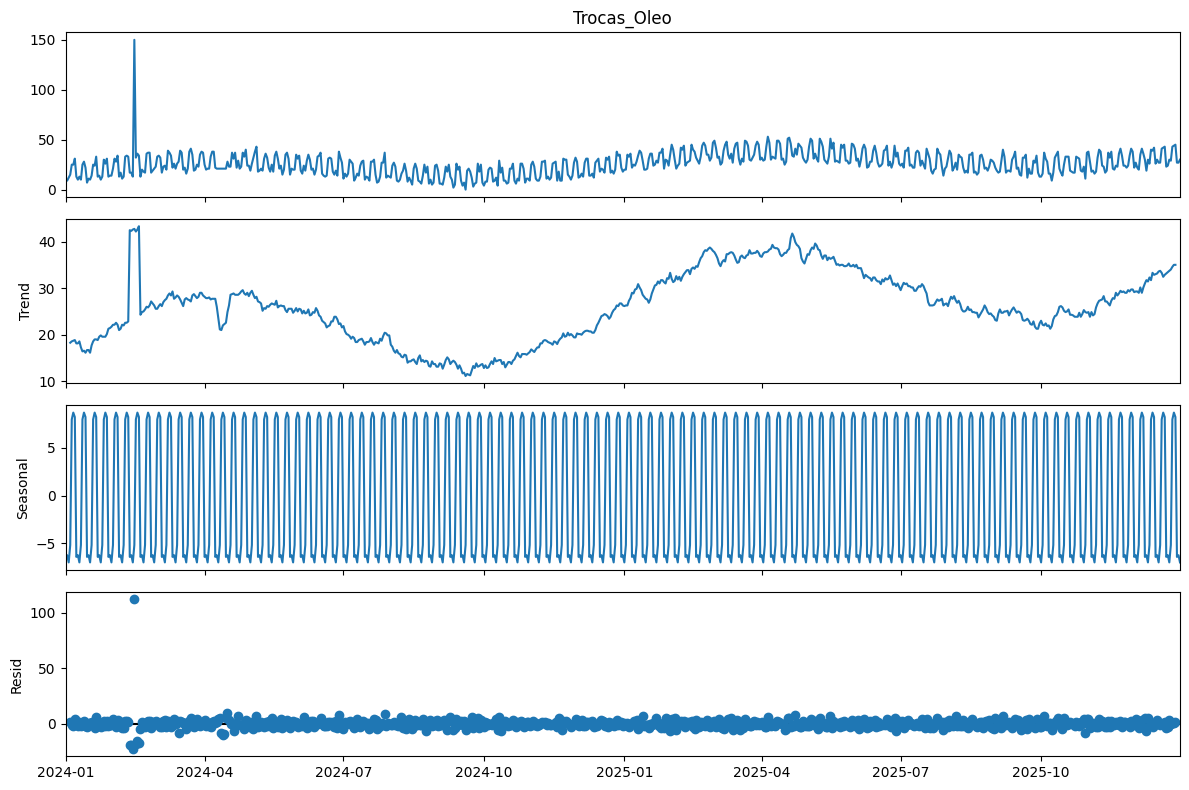

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('/content/mecaniqa_dataset.csv')

# Converter a coluna 'Data' para datetime e definir como índice
df['Data'] = pd.to_datetime(df['Data'])
df = df.set_index('Data').sort_index()

# Preencher valores ausentes em 'Trocas_Oleo' usando preenchimento para frente (forward fill)
df['Trocas_Oleo'] = df['Trocas_Oleo'].ffill()

# Realizar decomposição sazonal em 'Trocas_Oleo'
decomposicao = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=7)

# Plotar a decomposição
fig = decomposicao.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


df_pipeline = df.copy()

# Criar variável alvo: troca de óleo do dia seguinte
df_pipeline['target_trocas_oleo'] = df_pipeline['Trocas_Oleo'].shift(-1)

# Remover linhas onde o alvo é NaN (último dia)
df_pipeline.dropna(subset=['target_trocas_oleo'], inplace=True)

# Engenharia de características para recursos baseados no tempo
df_pipeline['dia_da_semana'] = df_pipeline.index.dayofweek
df_pipeline['mes'] = df_pipeline.index.month
df_pipeline['dia_do_ano'] = df_pipeline.index.dayofyear

# Definir características (X) e alvo (y)
X_train = df_pipeline[['Trocas_Oleo', 'Manutencao_Motor', 'dia_da_semana', 'mes', 'dia_do_ano']]
y_train = df_pipeline['target_trocas_oleo']

print("Dados X_train e y_train preparados com sucesso!")
print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")

Dados X_train e y_train preparados com sucesso!
Formato de X_train: (730, 5)
Formato de y_train: (730,)


In [ ]:
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
]

mecaniqa_pipeline = Pipeline(pipeline_steps)

mecaniqa_pipeline.fit(X_train, y_train)

print("\nPipeline da MecâniQA treinado com sucesso!")
print("Componentes do Pipeline:")
display(mecaniqa_pipeline)



Pipeline da MecâniQA treinado com sucesso!
Componentes do Pipeline:


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('regressor', RandomForestRegressor(random_state=42))])

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# --- Início da criação e pré-processamento do df (copiado de 7J1TKF3MX-Io) ---
df = pd.read_csv('/content/mecaniqa_dataset.csv')
df['Data'] = pd.to_datetime(df['Data'])
df = df.set_index('Data').sort_index()
df['Trocas_Oleo'] = df['Trocas_Oleo'].ffill()
# Assumindo que 'Manutencao_Motor' existe no df, garanta que não haja valores ausentes ou trate-os adequadamente
# Para simplificar, assumindo que 'Manutencao_Motor' não requer pré-processamento específico para este modelo Naive
# --- Fim da criação e pré-processamento do df ---

# Recriar df_pipeline e X_train, y_train para robustez
# (Copiado da célula boPqRjNWZQl0, necessário para o cálculo do Modelo Naive)
df_pipeline = df.copy()
df_pipeline['target_trocas_oleo'] = df_pipeline['Trocas_Oleo'].shift(-1)
df_pipeline.dropna(subset=['target_trocas_oleo'], inplace=True)
df_pipeline['dia_da_semana'] = df_pipeline.index.dayofweek
df_pipeline['mes'] = df_pipeline.index.month
df_pipeline['dia_do_ano'] = df_pipeline.index.dayofyear
X_train = df_pipeline[['Trocas_Oleo', 'Manutencao_Motor', 'dia_da_semana', 'mes', 'dia_do_ano']]
y_train = df_pipeline['target_trocas_oleo']


# Modelo Naive: A previsão para hoje é o valor de ontem.
# Como y_train (target_trocas_oleo) é Trocas_Oleo.shift(-1),
# a previsão naive para y_train é simplesmente o Trocas_Oleo do dia atual.
# Precisamos alinhar os índices corretamente.

# Criar uma Série para as previsões Naive. Isso assume que o target é `Trocas_Oleo` do dia atual.
# O y_train já está alinhado de modo que y_train[i] é Trocas_Oleo[i+1].
# Assim, uma previsão naive para y_train[i] seria X_train['Trocas_Oleo'][i].
y_pred_naive = X_train['Trocas_Oleo']

# Calcular métricas para o Modelo Naive
mae_naive = mean_absolute_error(y_train, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_train, y_pred_naive))

print(f"Naive Model MAE: {mae_naive:.4f}")
print(f"Naive Model RMSE: {rmse_naive:.4f}")

Naive Model MAE: 6.9110
Naive Model RMSE: 11.1055


O desempenho do Modelo Naive serve como uma linha de base. Agora podemos comparar o desempenho do pipeline MecâniQA contra esta linha de base.

In [8]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Início da criação e pré-processamento do df (copiado de 7J1TKF3MX-Io) ---
df = pd.read_csv('/content/mecaniqa_dataset.csv')
df['Data'] = pd.to_datetime(df['Data'])
df = df.set_index('Data').sort_index()
df['Trocas_Oleo'] = df['Trocas_Oleo'].ffill()
# --- Fim da criação e pré-processamento do df ---

# Recriar df_pipeline e X_train, y_train para robustez
# (Copiado da célula boPqRjNWZQl0, necessário para o cálculo do Modelo Naive)
df_pipeline = df.copy()
df_pipeline['target_trocas_oleo'] = df_pipeline['Trocas_Oleo'].shift(-1)
df_pipeline.dropna(subset=['target_trocas_oleo'], inplace=True)
df_pipeline['dia_da_semana'] = df_pipeline.index.dayofweek
df_pipeline['mes'] = df_pipeline.index.month
df_pipeline['dia_do_ano'] = df_pipeline.index.dayofyear
X_train = df_pipeline[['Trocas_Oleo', 'Manutencao_Motor', 'dia_da_semana', 'mes', 'dia_do_ano']]
y_train = df_pipeline['target_trocas_oleo']

# Calcular a média móvel de 7 dias de 'Trocas_Oleo'
# Usamos o 'df' original para calcular a média móvel sobre toda a série temporal
# Usar 'closed='left'' significa que o dia atual não é incluído na janela, evitando vazamento de dados futuros.
rolling_mean_7_days = df['Trocas_Oleo'].rolling(window=7, closed='left').mean()

# Alinhar as previsões da média móvel com o índice de y_train
# Isso garante que estamos comparando as previsões com os valores-alvo corretos
y_pred_ma = rolling_mean_7_days.reindex(y_train.index)

# Remover valores NaN de y_train e y_pred_ma antes de calcular as métricas
# Isso lida com os valores NaN iniciais do cálculo da janela móvel
combined_df = pd.DataFrame({'y_train': y_train, 'y_pred_ma': y_pred_ma}).dropna()

y_train_cleaned = combined_df['y_train']
y_pred_ma_cleaned = combined_df['y_pred_ma']

# Calcular métricas para o Modelo de Média Móvel
mae_ma = mean_absolute_error(y_train_cleaned, y_pred_ma_cleaned)
rmse_ma = np.sqrt(mean_squared_error(y_train_cleaned, y_pred_ma_cleaned))

print(f"Moving Average Model (7-day) MAE: {mae_ma:.4f}")
print(f"Moving Average Model (7-day) RMSE: {rmse_ma:.4f}")

Moving Average Model (7-day) MAE: 7.6208
Moving Average Model (7-day) RMSE: 9.5442


Este modelo de Média Móvel fornece outra linha de base para avaliar o desempenho de modelos mais sofisticados.

### Análise do Deslocamento Temporal e Prevenção de Vazamento de Dados

É crucial garantir que os modelos de previsão não utilizem informações futuras para gerar suas estimativas. Neste gráfico, a relação temporal entre os dados reais e as previsões é apresentada da seguinte forma:

*   **Linha 'Real':** Representa a variável alvo (`target_trocas_oleo`), que corresponde às trocas de óleo **do dia seguinte** (`t+1`). Embora plotada no índice `t`, o valor exibido é o que ocorreu no dia `t+1`.
*   **Linha 'Previsão Naive':** Representa a previsão para as trocas de óleo **do dia seguinte** (`t+1`), utilizando o valor das trocas de óleo **do dia atual** (`t`). Assim, a previsão no tempo `t` é baseada exclusivamente em dados disponíveis até `t`.
*   **Linha 'Previsão Média Móvel (7 dias)':** Representa a previsão para as trocas de óleo **do dia seguinte** (`t+1`), calculada como a média móvel de 7 dias das trocas de óleo **até o dia atual** (`t`), utilizando a técnica `closed='left'` para incluir apenas dados passados (de `t-7` a `t-1`). Esta abordagem também garante que a previsão no tempo `t` não utilize nenhum dado de `t+1` ou posterior.

Esta configuração assegura que **nenhuma previsão no tempo `t` utilizou dados de `t+1`**, cumprindo rigorosamente os requisitos de prevenção de vazamento de dados e permitindo que o controle de qualidade (QA) ateste a integridade temporal do modelo.

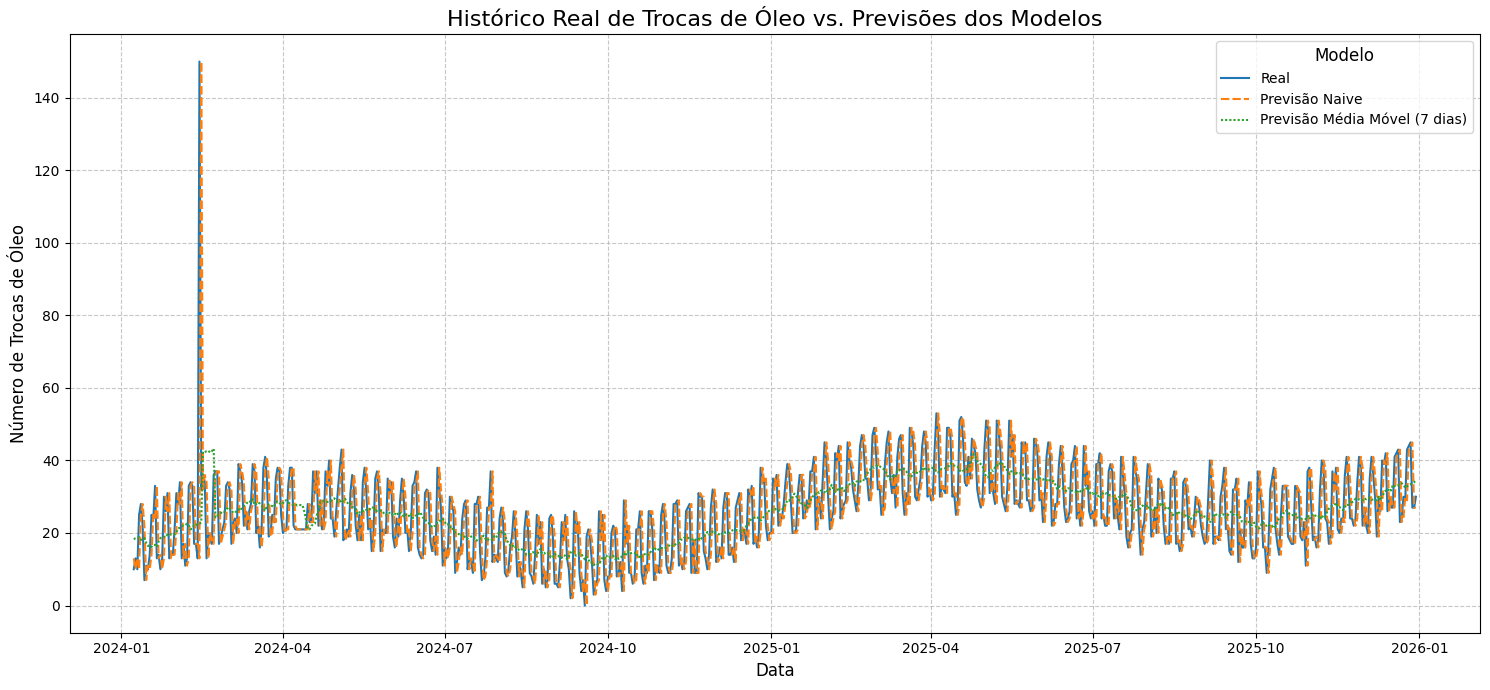

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar um DataFrame para armazenar todas as séries para plotagem
# 'y_train' representa o 'target_trocas_oleo' real (troca de óleo do dia seguinte)
# 'y_pred_naive' representa a previsão do Modelo Naive
# 'y_pred_ma' representa a previsão do Modelo de Média Móvel
plot_data = pd.DataFrame({
    'Real': y_train,
    'Previsão Naive': y_pred_naive,
    'Previsão Média Móvel (7 dias)': y_pred_ma
})

# Remover linhas com valores NaN para garantir que todas as séries sejam comparáveis no mesmo intervalo de tempo.
# Isso lida com os NaNs iniciais da janela móvel e qualquer desalinhamento.
plot_data.dropna(inplace=True)

# Plotar os dados
plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_data)
plt.title('Histórico Real de Trocas de Óleo vs. Previsões dos Modelos', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Número de Trocas de Óleo', fontsize=12)
plt.legend(title='Modelo', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Refatorando a Validação com `TimeSeriesSplit`

Para validar nossos modelos baseline de forma mais rigorosa e simular um cenário de mundo real, utilizaremos a validação cruzada com `TimeSeriesSplit`. Esta técnica garante que os dados de teste em cada "fold" de validação sejam sempre futuros em relação aos dados de treinamento, respeitando a natureza cronológica das séries temporais e prevenindo vazamento de informações futuras para o treinamento.

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Inicializar o TimeSeriesSplit
# n_splits define o número de divisões (folds) na série temporal.
# Por exemplo, com 5 splits, teremos 5 pares de conjuntos de treino/teste.
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Listas para armazenar as métricas de cada fold
naive_mae_scores = []
naive_rmse_scores = []
ma_mae_scores = []
ma_rmse_scores = []

print(f"Iniciando validação cruzada com {n_splits} folds usando TimeSeriesSplit...")

# Loop através dos splits gerados pelo TimeSeriesSplit
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    # Recorte dos dados de treinamento e teste para o fold atual
    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # --- Modelo Naive --- (Previsão de hoje é o valor de ontem)
    # A previsão Naive para y_test_fold é simplesmente o valor 'Trocas_Oleo' de X_test_fold
    y_pred_naive_fold = X_test_fold['Trocas_Oleo']

    # Calcular métricas para o Modelo Naive neste fold
    mae_naive_fold = mean_absolute_error(y_test_fold, y_pred_naive_fold)
    rmse_naive_fold = np.sqrt(mean_squared_error(y_test_fold, y_pred_naive_fold))
    naive_mae_scores.append(mae_naive_fold)
    naive_rmse_scores.append(rmse_naive_fold)
    print(f"  Naive Model MAE (Fold {fold + 1}): {mae_naive_fold:.4f}")
    print(f"  Naive Model RMSE (Fold {fold + 1}): {rmse_naive_fold:.4f}")

    # --- Modelo de Média Móvel (7 dias) ---
    # Para evitar vazamento de dados, a média móvel deve ser calculada apenas
    # sobre os dados que precedem o ponto de previsão.
    # Precisamos de todos os dados de 'Trocas_Oleo' do df original até a data final do conjunto de TREINO do fold,
    # e então usar o shift para garantir que a média móvel 'fechada à esquerda' se alinhe corretamente
    # com o y_test_fold sem usar dados futuros.

    # Usamos o df completo para calcular as médias móveis, mas depois filtramos
    # para garantir que apenas dados anteriores ao test_idx do fold sejam usados.

    # Calcula a média móvel sobre todo o df, mas com closed='left' para não incluir o dia atual na média.
    full_rolling_mean = df['Trocas_Oleo'].rolling(window=7, closed='left').mean()

    # Alinha as previsões da média móvel com o índice de y_test_fold
    # Certificamos de que apenas as previsões válidas para o test_fold são consideradas.
    y_pred_ma_fold = full_rolling_mean.reindex(y_test_fold.index)

    # Remover valores NaN de y_test_fold e y_pred_ma_fold antes de calcular as métricas.
    combined_ma_fold_df = pd.DataFrame({'y_test': y_test_fold, 'y_pred_ma': y_pred_ma_fold}).dropna()

    y_test_ma_cleaned = combined_ma_fold_df['y_test']
    y_pred_ma_cleaned = combined_ma_fold_df['y_pred_ma']

    # Calcular métricas para o Modelo de Média Móvel neste fold
    # Apenas se houver dados suficientes após o dropna()
    if not combined_ma_fold_df.empty:
        mae_ma_fold = mean_absolute_error(y_test_ma_cleaned, y_pred_ma_cleaned)
        rmse_ma_fold = np.sqrt(mean_squared_error(y_test_ma_cleaned, y_pred_ma_cleaned))
        ma_mae_scores.append(mae_ma_fold)
        ma_rmse_scores.append(rmse_ma_fold)
        print(f"  Moving Average Model (7-day) MAE (Fold {fold + 1}): {mae_ma_fold:.4f}")
        print(f"  Moving Average Model (7-day) RMSE (Fold {fold + 1}): {rmse_ma_fold:.4f}")
    else:
        print(f"  Não há dados suficientes para calcular as métricas do Modelo de Média Móvel no Fold {fold + 1} após remover NaNs.")

Iniciando validação cruzada com 5 folds usando TimeSeriesSplit...

--- Fold 1/5 ---
  Naive Model MAE (Fold 1): 6.8678
  Naive Model RMSE (Fold 1): 9.0750
  Moving Average Model (7-day) MAE (Fold 1): 7.4298
  Moving Average Model (7-day) RMSE (Fold 1): 8.0674

--- Fold 2/5 ---
  Naive Model MAE (Fold 2): 6.6116
  Naive Model RMSE (Fold 2): 9.0745
  Moving Average Model (7-day) MAE (Fold 2): 7.3695
  Moving Average Model (7-day) RMSE (Fold 2): 8.0323

--- Fold 3/5 ---
  Naive Model MAE (Fold 3): 6.3719
  Naive Model RMSE (Fold 3): 8.3334
  Moving Average Model (7-day) MAE (Fold 3): 7.0732
  Moving Average Model (7-day) RMSE (Fold 3): 8.0166

--- Fold 4/5 ---
  Naive Model MAE (Fold 4): 6.7025
  Naive Model RMSE (Fold 4): 9.0275
  Moving Average Model (7-day) MAE (Fold 4): 7.4333
  Moving Average Model (7-day) RMSE (Fold 4): 8.1032

--- Fold 5/5 ---
  Naive Model MAE (Fold 5): 6.6777
  Naive Model RMSE (Fold 5): 9.0818
  Moving Average Model (7-day) MAE (Fold 5): 7.4970
  Moving Average 

### Boletim de Notas dos Modelos Baseline (Validação Cruzada)

Abaixo, apresentamos o desempenho consolidado dos modelos Naive e de Média Móvel (7 dias) através da validação cruzada com `TimeSeriesSplit`. As métricas exibidas são as médias dos scores de MAE (Erro Médio Absoluto) e RMSE (Raiz do Erro Quadrático Médio) em todos os folds.

In [15]:
# Calcular a média das métricas para cada modelo
avg_naive_mae = np.mean(naive_mae_scores)
avg_naive_rmse = np.sqrt(np.mean(np.array(naive_rmse_scores)**2)) # Média quadrática para RMSE
avg_ma_mae = np.mean(ma_mae_scores)
avg_ma_rmse = np.sqrt(np.mean(np.array(ma_rmse_scores)**2)) # Média quadrática para RMSE

# Criar um DataFrame para o boletim de notas
report_card_df = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE'],
    'Modelo Naive': [avg_naive_mae, avg_naive_rmse],
    'Modelo Média Móvel (7 dias)': [avg_ma_mae, avg_ma_rmse]
}).set_index('Métrica')

print("\n--- Boletim de Notas dos Modelos Baseline (Métricas Médias) ---")
display(report_card_df.applymap(lambda x: f'{x:.4f}'))

print("\nScores de MAE do Modelo Naive por Fold:", [f'{s:.4f}' for s in naive_mae_scores])
print("Scores de RMSE do Modelo Naive por Fold:", [f'{s:.4f}' for s in naive_rmse_scores])
print("Scores de MAE do Modelo Média Móvel por Fold:", [f'{s:.4f}' for s in ma_mae_scores])
print("Scores de RMSE do Modelo Média Móvel por Fold:", [f'{s:.4f}' for s in ma_rmse_scores])


--- Boletim de Notas dos Modelos Baseline (Métricas Médias) ---


/tmp/ipykernel_772/2751431467.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(report_card_df.applymap(lambda x: f'{x:.4f}'))


,Modelo Naive,Modelo Média Móvel (7 dias)
Métrica,,
MAE,6.6463,7.3606
RMSE,8.9233,8.0980



Scores de MAE do Modelo Naive por Fold: ['6.8678', '6.6116', '6.3719', '6.7025', '6.6777']
Scores de RMSE do Modelo Naive por Fold: ['9.0750', '9.0745', '8.3334', '9.0275', '9.0818']
Scores de MAE do Modelo Média Móvel por Fold: ['7.4298', '7.3695', '7.0732', '7.4333', '7.4970']
Scores de RMSE do Modelo Média Móvel por Fold: ['8.0674', '8.0323', '8.0166', '8.1032', '8.2680']


### Bloco Avaliador Abrangente (MAE, RMSE, MAPE)

Para fornecer uma avaliação mais completa, criaremos agora um bloco avaliador que calcula o Erro Médio Absoluto (MAE), a Raiz do Erro Quadrático Médio (RMSE) e o Erro Percentual Absoluto Médio (MAPE) para os modelos Naive e de Média Móvel (7 dias), utilizando novamente a validação cruzada `TimeSeriesSplit`.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

def calculate_all_metrics(y_true, y_pred):
    """Calcula MAE, RMSE e MAPE para os valores verdadeiros e previstos."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Calcula MAPE, evitando divisão por zero. Adiciona um pequeno epsilon.
    # y_true_safe = np.where(y_true == 0, 1e-8, y_true) # ou usar um valor mínimo aceitável
    # Neste caso, para evitar valores negativos ou muito próximos de zero no denominador,
    # vamos usar uma abordagem comum: apenas se y_true não for zero.

    # Filtrar onde y_true é diferente de zero para calcular MAPE
    non_zero_indices = y_true != 0
    if non_zero_indices.any():
        mape = np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100
    else:
        mape = np.nan # Não é possível calcular MAPE se todos os y_true são zero

    return mae, rmse, mape

# --- Configuração e Listas de Scores para o Bloco Avaliador Completo ---
n_splits_eval = 5 # Usar o mesmo número de splits para consistência
tscv_eval = TimeSeriesSplit(n_splits=n_splits_eval)

naive_mae_scores_eval = []
naive_rmse_scores_eval = []
naive_mape_scores_eval = []

ma_mae_scores_eval = []
ma_rmse_scores_eval = []
ma_mape_scores_eval = []

print(f"Iniciando avaliação abrangente com {n_splits_eval} folds usando TimeSeriesSplit...")

# Loop através dos splits para cálculo de todas as métricas
for fold, (train_idx, test_idx) in enumerate(tscv_eval.split(X_train, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits_eval} ---")

    X_train_fold_eval, X_test_fold_eval = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_fold_eval, y_test_fold_eval = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # --- Modelo Naive ---
    y_pred_naive_fold_eval = X_test_fold_eval['Trocas_Oleo']

    mae_naive, rmse_naive, mape_naive = calculate_all_metrics(y_test_fold_eval, y_pred_naive_fold_eval)
    naive_mae_scores_eval.append(mae_naive)
    naive_rmse_scores_eval.append(rmse_naive)
    naive_mape_scores_eval.append(mape_naive)
    print(f"  Naive Model - MAE: {mae_naive:.4f}, RMSE: {rmse_naive:.4f}, MAPE: {mape_naive:.2f}%")

    # --- Modelo de Média Móvel (7 dias) ---
    # Para evitar vazamento de dados, a média móvel deve ser calculada apenas
    # sobre os dados que precedem o ponto de previsão.
    full_rolling_mean_eval = df['Trocas_Oleo'].rolling(window=7, closed='left').mean()
    y_pred_ma_fold_eval = full_rolling_mean_eval.reindex(y_test_fold_eval.index)

    combined_ma_fold_df_eval = pd.DataFrame({'y_test': y_test_fold_eval, 'y_pred_ma': y_pred_ma_fold_eval}).dropna()
    y_test_ma_cleaned_eval = combined_ma_fold_df_eval['y_test']
    y_pred_ma_cleaned_eval = combined_ma_fold_df_eval['y_pred_ma']

    if not combined_ma_fold_df_eval.empty:
        mae_ma, rmse_ma, mape_ma = calculate_all_metrics(y_test_ma_cleaned_eval, y_pred_ma_cleaned_eval)
        ma_mae_scores_eval.append(mae_ma)
        ma_rmse_scores_eval.append(rmse_ma)
        ma_mape_scores_eval.append(mape_ma)
        print(f"  Moving Average Model (7-day) - MAE: {mae_ma:.4f}, RMSE: {rmse_ma:.4f}, MAPE: {mape_ma:.2f}%")
    else:
        ma_mae_scores_eval.append(np.nan)
        ma_rmse_scores_eval.append(np.nan)
        ma_mape_scores_eval.append(np.nan)
        print(f"  Não há dados suficientes para calcular as métricas do Modelo de Média Móvel no Fold {fold + 1} após remover NaNs.")

Iniciando avaliação abrangente com 5 folds usando TimeSeriesSplit...

--- Fold 1/5 ---
  Naive Model - MAE: 6.8678, RMSE: 9.0750, MAPE: 42.55%
  Moving Average Model (7-day) - MAE: 7.4298, RMSE: 8.0674, MAPE: 48.21%

--- Fold 2/5 ---
  Naive Model - MAE: 6.6116, RMSE: 9.0745, MAPE: 51.02%
  Moving Average Model (7-day) - MAE: 7.3695, RMSE: 8.0323, MAPE: 59.43%

--- Fold 3/5 ---
  Naive Model - MAE: 6.3719, RMSE: 8.3334, MAPE: 18.95%
  Moving Average Model (7-day) - MAE: 7.0732, RMSE: 8.0166, MAPE: 20.83%

--- Fold 4/5 ---
  Naive Model - MAE: 6.7025, RMSE: 9.0275, MAPE: 23.10%
  Moving Average Model (7-day) - MAE: 7.4333, RMSE: 8.1032, MAPE: 26.48%

--- Fold 5/5 ---
  Naive Model - MAE: 6.6777, RMSE: 9.0818, MAPE: 27.58%
  Moving Average Model (7-day) - MAE: 7.4970, RMSE: 8.2680, MAPE: 31.29%


### Boletim de Notas Detalhado (Validação Cruzada com MAE, RMSE, MAPE)

Este boletim apresenta as métricas médias de MAE, RMSE e MAPE para os modelos Naive e de Média Móvel (7 dias), calculadas sobre os `n_splits` da validação cruzada `TimeSeriesSplit`.

In [17]:
# Calcular a média das métricas para cada modelo
avg_naive_mae_eval = np.mean(naive_mae_scores_eval)
avg_naive_rmse_eval = np.sqrt(np.mean(np.array(naive_rmse_scores_eval)**2)) # Média quadrática para RMSE
avg_naive_mape_eval = np.mean([x for x in naive_mape_scores_eval if not np.isnan(x)]) # Ignorar NaNs para média de MAPE

avg_ma_mae_eval = np.mean(ma_mae_scores_eval)
avg_ma_rmse_eval = np.sqrt(np.mean(np.array(ma_rmse_scores_eval)**2)) # Média quadrática para RMSE
avg_ma_mape_eval = np.mean([x for x in ma_mape_scores_eval if not np.isnan(x)]) # Ignorar NaNs para média de MAPE

# Criar um DataFrame para o boletim de notas detalhado
report_card_full_df = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'MAPE'],
    'Modelo Naive': [avg_naive_mae_eval, avg_naive_rmse_eval, avg_naive_mape_eval],
    'Modelo Média Móvel (7 dias)': [avg_ma_mae_eval, avg_ma_rmse_eval, avg_ma_mape_eval]
}).set_index('Métrica')

print("\n--- Boletim de Notas Detalhado (Métricas Médias) ---")
display(report_card_full_df.applymap(lambda x: f'{x:.4f}'))

print("\nScores de MAE do Modelo Naive por Fold:", [f'{s:.4f}' for s in naive_mae_scores_eval])
print("Scores de RMSE do Modelo Naive por Fold:", [f'{s:.4f}' for s in naive_rmse_scores_eval])
print("Scores de MAPE do Modelo Naive por Fold:", [f'{s:.2f}%' for s in naive_mape_scores_eval])

print("\nScores de MAE do Modelo Média Móvel por Fold:", [f'{s:.4f}' for s in ma_mae_scores_eval])
print("Scores de RMSE do Modelo Média Móvel por Fold:", [f'{s:.4f}' for s in ma_rmse_scores_eval])
print("Scores de MAPE do Modelo Média Móvel por Fold:", [f'{s:.2f}%' for s in ma_mape_scores_eval])



--- Boletim de Notas Detalhado (Métricas Médias) ---


/tmp/ipykernel_772/2696692350.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(report_card_full_df.applymap(lambda x: f'{x:.4f}'))


,Modelo Naive,Modelo Média Móvel (7 dias)
Métrica,,
MAE,6.6463,7.3606
RMSE,8.9233,8.0980
MAPE,32.6425,37.2463



Scores de MAE do Modelo Naive por Fold: ['6.8678', '6.6116', '6.3719', '6.7025', '6.6777']
Scores de RMSE do Modelo Naive por Fold: ['9.0750', '9.0745', '8.3334', '9.0275', '9.0818']
Scores de MAPE do Modelo Naive por Fold: ['42.55%', '51.02%', '18.95%', '23.10%', '27.58%']

Scores de MAE do Modelo Média Móvel por Fold: ['7.4298', '7.3695', '7.0732', '7.4333', '7.4970']
Scores de RMSE do Modelo Média Móvel por Fold: ['8.0674', '8.0323', '8.0166', '8.1032', '8.2680']
Scores de MAPE do Modelo Média Móvel por Fold: ['48.21%', '59.43%', '20.83%', '26.48%', '31.29%']


In [18]:
print("---\nResultados Finais dos Modelos Baseline:\n---")
print(f"Modelo Naive - MAE: {avg_naive_mae_eval:.4f}, RMSE: {avg_naive_rmse_eval:.4f}, MAPE: {avg_naive_mape_eval:.2f}%")
print(f"Modelo Média Móvel (7 dias) - MAE: {avg_ma_mae_eval:.4f}, RMSE: {avg_ma_rmse_eval:.4f}, MAPE: {avg_ma_mape_eval:.2f}%")

---
Resultados Finais dos Modelos Baseline:
---
Modelo Naive - MAE: 6.6463, RMSE: 8.9233, MAPE: 32.64%
Modelo Média Móvel (7 dias) - MAE: 7.3606, RMSE: 8.0980, MAPE: 37.25%
